# 09 - Pipeline `two-stream` (Optuna-tuned)

RGB CNN + frequency (FFT) CNN -> fusion, with per-stream auxiliary heads.

**Sections:** 0 Setup - 1 Data - 2 Hyperparameter search (Optuna) - 3 Final train - 4 Curves - 5 In-dist eval - 6 OOD preview - 7 Explainability - 8 metrics.json

Training is **Optuna-driven**: a search maximizes val AUC (with pruning), the winner is saved, and the final model is trained on it. Set `TUNE=False` to skip the search and reuse the committed `best_params.json`. Artifacts -> `notebooks/artifacts/two-stream/{models,figures,metrics,tuning}`.

## 0 - Setup

In [1]:
import sys, time, json, gc
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython.display import display
import optuna

_here = Path.cwd()
_nb_dir = _here if (_here / "utils").is_dir() else _here / "notebooks"
if str(_nb_dir) not in sys.path:
    sys.path.insert(0, str(_nb_dir))

from utils import datasets as D, models as M, training as T, metrics as Me, viz as V, explain as E, eda, tuning as TU
from utils.paths import repo_paths, artifact_dirs

optuna.logging.set_verbosity(optuna.logging.WARNING)
torch.manual_seed(42); np.random.seed(42)
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision("high")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PATHS = repo_paths(_nb_dir)
DATA_DIR = PATHS["data"]
AIR_DIR = DATA_DIR / "ai-real-images"
SPLIT_PATH = AIR_DIR / "manifest_split.csv"
TINY_MANIFEST = DATA_DIR / "tiny-genimage" / "manifest_clean.csv"

PIPELINE = "two-stream"
WORKING_SIZE = 128
NORM = "dataset"
BATCH_SIZE = 128
TUNE = True
N_TRIALS = 20
SEARCH_EPOCHS = 10
FINAL_EPOCHS = 40
WARMUP_EPOCHS = 3
NUM_WORKERS = 8
dirs = artifact_dirs(PIPELINE)
print("device:", device, "| pipeline:", PIPELINE)

device: cuda | pipeline: two-stream


## (GPU clean)

In [2]:
# Clear the GPU at the very start (frees this process's CUDA cache + reports free VRAM).
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache(); torch.cuda.ipc_collect()
    free_b, total_b = torch.cuda.mem_get_info()
    print(f"GPU cleaned - free {free_b / 1e9:.1f} / {total_b / 1e9:.1f} GB")
else:
    print("CPU mode - nothing to clean")

GPU cleaned - free 11.8 / 12.9 GB


## 1 - Data

In [3]:
loaders = D.make_loaders(SPLIT_PATH, working_size=WORKING_SIZE, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, norm=NORM)
train_loader, val_loader, test_loader = loaders["train"], loaders["val"], loaders["test"]
mean, std = D.resolve_stats(NORM, AIR_DIR)
split_df = pd.read_csv(SPLIT_PATH); split_df = split_df[split_df["keep"]]
test_df = split_df[split_df["split_final"] == "test"].reset_index(drop=True)
print(f"train {len(train_loader.dataset):,} | val {len(val_loader.dataset):,} | test {len(test_loader.dataset):,}")

train 43,127 | val 4,792 | test 11,963


## 2 - Hyperparameter search (Optuna)

Joint training of all branches + fusion; each trial reports the fused val AUC. Loss = fused + aux_weight * sum(per-stream).

In [4]:
SEARCH_SPACE = {
    "feat": {"type": "categorical", "choices": [128, 256, 384]},
    "aux_weight": {"type": "float", "low": 0.1, "high": 0.7},
    "p_drop": {"type": "float", "low": 0.1, "high": 0.5},
    "lr": {"type": "loguniform", "low": 1e-3, "high": 3e-3},
    "weight_decay": {"type": "loguniform", "low": 5e-4, "high": 2e-3},
    "label_smooth": {"type": "float", "low": 0.0, "high": 0.1},
    "loss": {"type": "categorical", "choices": ["bce", "focal"]},
}
DEFAULTS = {"feat": 256, "aux_weight": 0.5, "p_drop": 0.3, "lr": 2e-3, "weight_decay": 1e-3, "label_smooth": 0.05, "loss": "bce"}

def _train_aux(model, p, epochs, trial=None):
    loss_fn = TU.make_loss(p["loss"], p.get("focal_gamma", 2.0))
    opt = torch.optim.AdamW(model.parameters(), lr=p["lr"], weight_decay=p["weight_decay"])
    spe = len(train_loader); sched = T.build_cosine_with_warmup(opt, total_steps=epochs * spe, warmup_steps=max(1, spe // 3))
    best = 0.0
    for ep in range(epochs):
        model.train()
        for x, y in train_loader:
            x = x.to(device, memory_format=torch.channels_last, non_blocking=True); y = y.to(device, non_blocking=True).float()
            ys = T.smooth_binary_targets(y, p["label_smooth"])
            with torch.autocast(device_type=device.type, dtype=torch.bfloat16, enabled=device.type == "cuda"):
                out = model.forward_all(x); fused = out[0]; aux = out[1:]
                loss = loss_fn(fused, ys) + p["aux_weight"] * sum(loss_fn(a, ys) for a in aux)
            loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); opt.zero_grad(set_to_none=True); sched.step()
        yv, pv, _ = T.evaluate(model, val_loader, device); auc = Me.classification_metrics(yv, pv)["auc_roc"]
        best = max(best, auc)
        if trial is not None:
            TU.report_or_prune(trial, ep, auc)
    return best

def objective(trial):
    p = {
        "feat": trial.suggest_categorical("feat", [128, 256, 384]),
        "aux_weight": trial.suggest_float("aux_weight", 0.1, 0.7),
        "p_drop": trial.suggest_float("p_drop", 0.1, 0.5),
        "lr": trial.suggest_float("lr", 1e-3, 3e-3, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 5e-4, 2e-3, log=True),
        "label_smooth": trial.suggest_float("label_smooth", 0.0, 0.1),
        "loss": trial.suggest_categorical("loss", ["bce", "focal"]),
    }
    if p["loss"] == "focal":
        p["focal_gamma"] = trial.suggest_float("focal_gamma", 1.0, 3.0)
    model = M.build_two_stream(feat=p["feat"], p_drop=p["p_drop"]).to(device, memory_format=torch.channels_last)
    try:
        return _train_aux(model, p, SEARCH_EPOCHS, trial)
    finally:
        TU.cleanup(model)

def _cb(study, trial):
    v = trial.value if trial.value is not None else float("nan")
    print(f"  trial {trial.number:02d}: {trial.state.name:8s} value={v:.4f}")

TUNE_SUMMARY = {"tuned": bool(TUNE), "search_space": SEARCH_SPACE}
if TUNE:
    study = TU.make_study(PIPELINE, dirs["models"].parent / "tuning")
    study.optimize(objective, n_trials=N_TRIALS, callbacks=[_cb], gc_after_trial=True)
    TU.save_study_artifacts(study, SEARCH_SPACE, dirs["figures"], dirs["metrics"])
    best = {**DEFAULTS, **study.best_params}
    TUNE_SUMMARY.update(n_trials=len(study.trials), best_val_auc=float(study.best_value), best_params=best)
    print("\nBEST:", best, "| val_auc", round(study.best_value, 4))
else:
    best = TU.load_best_params(dirs["metrics"], DEFAULTS)
    TUNE_SUMMARY["best_params"] = best
    print("TUNE off -> using", best)

  trial 00: COMPLETE value=0.9268


  trial 01: COMPLETE value=0.9321


  trial 02: COMPLETE value=0.9286


  trial 03: COMPLETE value=0.9291


  trial 04: COMPLETE value=0.9284


...

  trial 18: PRUNED   value=0.8750


  trial 19: PRUNED   value=0.8652


C:\Users\user\Desktop\MSc - AI\Εξάμηνο 2ο\Βαθιά Μάθηση\deepfake-detection\notebooks\utils\tuning.py:143: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = fn(study)
C:\Users\user\Desktop\MSc - AI\Εξάμηνο 2ο\Βαθιά Μάθηση\deepfake-detection\notebooks\utils\tuning.py:143: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ax = fn(study)


C:\Users\user\Desktop\MSc - AI\Εξάμηνο 2ο\Βαθιά Μάθηση\deepfake-detection\notebooks\utils\tuning.py:143: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  ax = fn(study)
C:\Users\user\AppData\Roaming\Python\Python312\site-packages\optuna\visualization\matplotlib\_parallel_coordinate.py:115: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax2.set_ylim(dim.range[0], dim.range[1])



BEST: {'feat': 128, 'aux_weight': 0.20909498032426038, 'p_drop': 0.17336180394137352, 'lr': 0.0013968843144319682, 'weight_decay': 0.0010349154179321335, 'label_smooth': 0.04319450186421158, 'loss': 'focal', 'focal_gamma': 1.2789877213040837} | val_auc 0.9321


## 3 - Final train (best params, fused + auxiliary losses)

In [5]:
model = M.build_two_stream(feat=best["feat"], p_drop=best["p_drop"]).to(device, memory_format=torch.channels_last)
print("params:", f"{M.count_params(model):,}")
loss_fn = TU.make_loss(best["loss"], best.get("focal_gamma", 2.0))
optimizer = torch.optim.AdamW(model.parameters(), lr=best["lr"], weight_decay=best["weight_decay"])
spe = len(train_loader); scheduler = T.build_cosine_with_warmup(optimizer, total_steps=FINAL_EPOCHS * spe, warmup_steps=WARMUP_EPOCHS * spe)
stopper = T.EarlyStopper(mode="max", patience=7, min_delta=1e-3)
history = {"train_loss": [], "val_loss": [], "val_auc": [], "val_acc": []}
best_auc = -1.0; ckpt_path = dirs["models"] / "best.pt"
for epoch in range(FINAL_EPOCHS):
    t0 = time.time(); model.train(); running, n = 0.0, 0
    for x, y in train_loader:
        x = x.to(device, memory_format=torch.channels_last, non_blocking=True); y = y.to(device, non_blocking=True).float()
        ys = T.smooth_binary_targets(y, best["label_smooth"])
        with torch.autocast(device_type=device.type, dtype=torch.bfloat16, enabled=device.type == "cuda"):
            out = model.forward_all(x); fused = out[0]; aux = out[1:]
            loss = loss_fn(fused, ys) + best["aux_weight"] * sum(loss_fn(a, ys) for a in aux)
        loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); optimizer.zero_grad(set_to_none=True); scheduler.step()
        running += loss.item() * y.size(0); n += y.size(0)
    yv, pv, vloss = T.evaluate(model, val_loader, device, loss_fn); vm = Me.classification_metrics(yv, pv)
    history["train_loss"].append(running / n); history["val_loss"].append(vloss); history["val_auc"].append(vm["auc_roc"]); history["val_acc"].append(vm["accuracy"])
    improved, stop = stopper.step(vm["auc_roc"])
    if improved:
        best_auc = vm["auc_roc"]; T.save_checkpoint(ckpt_path, model, optimizer, epoch=epoch, best_metric=best_auc, extra={"history": history})
    print(f"epoch {epoch+1:02d} | val_auc {vm['auc_roc']:.4f} | {time.time()-t0:.0f}s{'  *best' if improved else ''}")
    if stop:
        print("early stopping"); break

params: 778,243


epoch 01 | val_auc 0.7978 | 55s  *best


epoch 02 | val_auc 0.8390 | 55s  *best


epoch 03 | val_auc 0.8449 | 55s  *best


epoch 04 | val_auc 0.8641 | 55s  *best


...

epoch 36 | val_auc 0.9615 | 55s


epoch 37 | val_auc 0.9616 | 55s


epoch 38 | val_auc 0.9621 | 55s


epoch 39 | val_auc 0.9617 | 55s


epoch 40 | val_auc 0.9618 | 55s


## 4 - Training curves

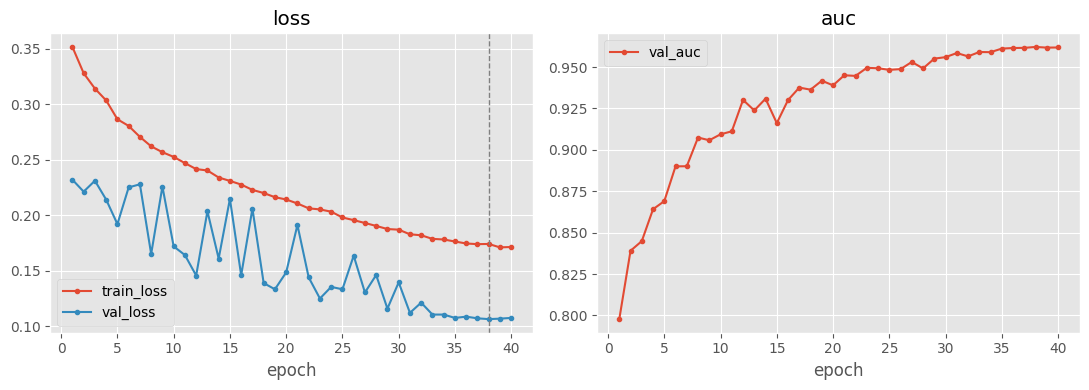

In [6]:
V.plot_training_curves(history).savefig(dirs["figures"] / "training_curves.png", dpi=150, bbox_inches="tight"); plt.show()

## 5 - In-distribution evaluation (+ per-component)

tuned threshold: 0.4844 | spatial auc 0.9596 | frequency auc 0.7673


,threshold,n,n_fake,n_real,accuracy,f1_macro,precision,recall,auc_roc,pr_auc,mcc,brier
0,0.5,11963,5977,5986,0.897685,0.897681,0.901911,0.892254,0.960944,0.96043,0.795413,0.086203


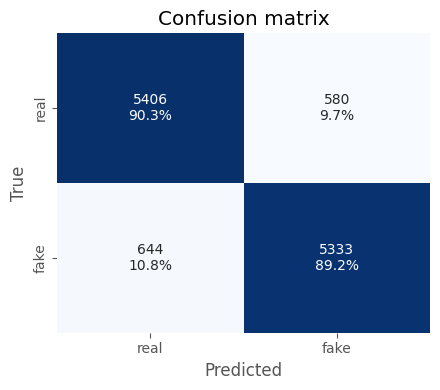

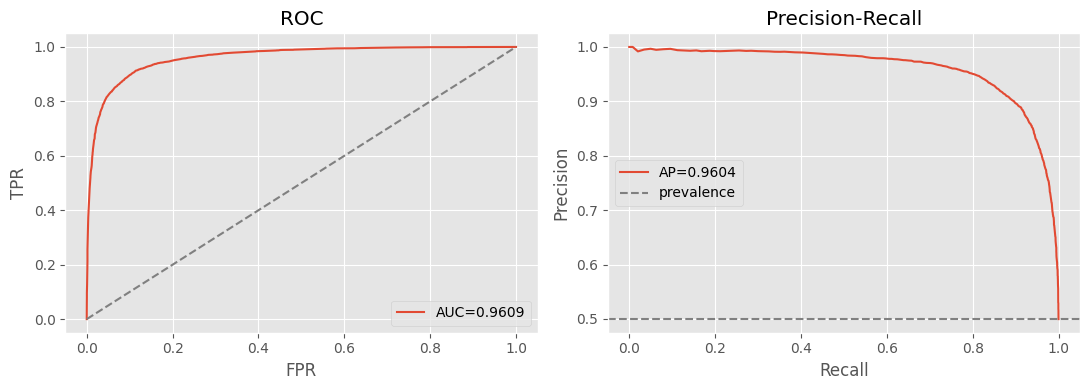

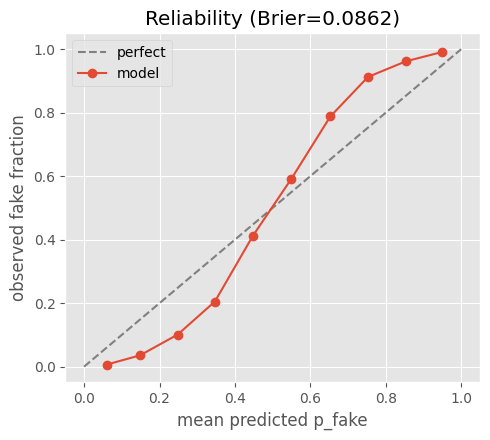

In [7]:
@torch.no_grad()
def eval_components(model, loader, device, names):
    model.eval(); P = {k: [] for k in ["fused"] + names}; Y = []
    for x, y in loader:
        x = x.to(device, memory_format=torch.channels_last, non_blocking=True)
        with torch.autocast(device_type=device.type, dtype=torch.bfloat16, enabled=device.type == "cuda"):
            out = model.forward_all(x)
        for k, v in zip(["fused"] + names, out):
            P[k].append(torch.sigmoid(v).float().cpu().numpy())
        Y.append(y.numpy())
    return np.concatenate(Y).astype(int), {k: np.concatenate(v) for k, v in P.items()}

COMP_NAMES = ["spatial", "frequency"] + (["radial"] if hasattr(model, "radial") else [])
T.load_checkpoint(ckpt_path, model, map_location=device)
yt, Pc = eval_components(model, test_loader, device, COMP_NAMES)
yv, pv, _ = T.evaluate(model, val_loader, device)
tuned = Me.best_f1_threshold(yv, pv)
m05 = Me.classification_metrics(yt, Pc["fused"], threshold=0.5)
mtuned = Me.classification_metrics(yt, Pc["fused"], threshold=tuned["threshold"])
comp = {k: Me.classification_metrics(yt, Pc[k]) for k in COMP_NAMES}
print("tuned threshold:", round(tuned["threshold"], 4), "| " + " | ".join(f"{k} auc {comp[k]['auc_roc']:.4f}" for k in COMP_NAMES))
display(Me.summary_table(m05))
V.plot_confusion(m05["confusion_matrix"]).savefig(dirs["figures"] / "confusion.png", dpi=150, bbox_inches="tight")
V.plot_roc_pr(yt, Pc["fused"]).savefig(dirs["figures"] / "roc_pr.png", dpi=150, bbox_inches="tight")
V.plot_reliability(yt, Pc["fused"]).savefig(dirs["figures"] / "reliability.png", dpi=150, bbox_inches="tight"); plt.show()

## 6 - Cross-generator (OOD) preview

,generator,accuracy,n
0,adm,0.548400,5000
1,biggan,0.401800,5000
2,glide,0.533400,5000
3,midjourney,0.670334,4999
4,sdv5,0.546109,4999
5,vqdm,0.377600,5000
6,wukong,0.607200,5000


overall OOD accuracy: 0.5264  (in-dist 0.8977)


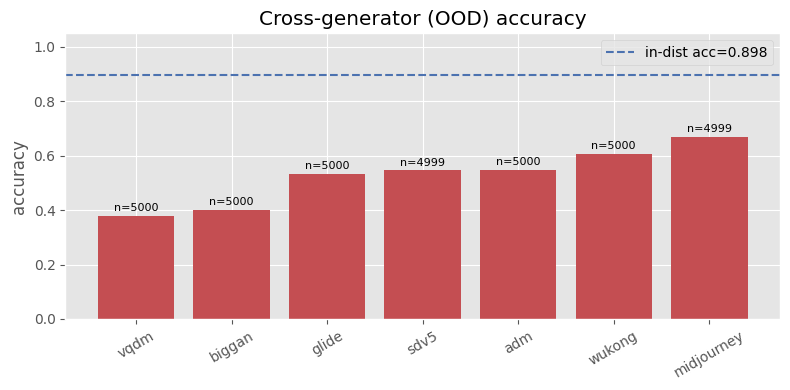

In [8]:
GEN_MAP = {
    "imagenet_ai_0419_biggan": "biggan", "imagenet_ai_0419_vqdm": "vqdm",
    "imagenet_ai_0424_sdv5": "sdv5", "imagenet_ai_0424_wukong": "wukong",
    "imagenet_ai_0508_adm": "adm", "imagenet_glide": "glide", "imagenet_midjourney": "midjourney",
}
ood_loader, ood_df = D.make_ood_loader(TINY_MANIFEST, WORKING_SIZE, BATCH_SIZE, mean, std, num_workers=NUM_WORKERS)
yo, po, _ = T.evaluate(model, ood_loader, device)
ood_df = ood_df.assign(p_fake=po, y_true=yo)
ood_df["y_pred"] = (ood_df["p_fake"] >= 0.5).astype(int)
ood_df["generator"] = ood_df["source"].map(GEN_MAP).fillna(ood_df["source"])
per_gen = pd.DataFrame([{"generator": g, "accuracy": float((d["y_pred"] == d["y_true"]).mean()), "n": int(len(d))} for g, d in ood_df.groupby("generator")])
overall_ood = float((ood_df["y_pred"] == ood_df["y_true"]).mean())
display(per_gen); print(f"overall OOD accuracy: {overall_ood:.4f}  (in-dist {m05['accuracy']:.4f})")
V.plot_per_generator_bar(per_gen, ref_acc=m05["accuracy"]).savefig(dirs["figures"] / "ood_per_generator.png", dpi=150, bbox_inches="tight"); plt.show()

## 7 - Explainability (Grad-CAM on the spatial branch)

C:\Users\user\AppData\Local\Temp\ipykernel_24956\2704151737.py:6: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_numpy.cpp:212.)
  arr = eda.read_rgb(ex["filepath"]); xt = eval_tf(torch.from_numpy(arr).permute(2, 0, 1)); x = xt.unsqueeze(0).to(device)


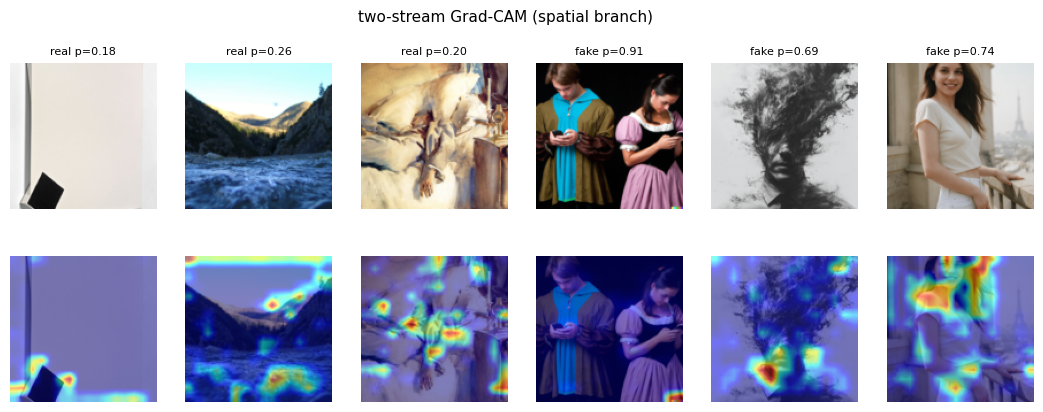

In [9]:
eval_tf = D.build_eval_tf(WORKING_SIZE, mean, std)
target_layers = [model.spatial.features[-1]]
examples = E.pick_examples(test_df, n_per_class=3, seed=0)
fig, axes = plt.subplots(2, len(examples), figsize=(2.2 * len(examples), 4.6)); model.eval()
for j, ex in enumerate(examples):
    arr = eda.read_rgb(ex["filepath"]); xt = eval_tf(torch.from_numpy(arr).permute(2, 0, 1)); x = xt.unsqueeze(0).to(device)
    rgb = D.denormalize(xt, mean, std).permute(1, 2, 0).numpy()
    with torch.no_grad():
        p = torch.sigmoid(model(x)).item()
    overlay = E.gradcam_overlay(model, target_layers, x, rgb)
    axes[0, j].imshow(rgb); axes[0, j].axis("off"); axes[0, j].set_title(f"{ex['label']} p={p:.2f}", fontsize=8)
    axes[1, j].imshow(overlay); axes[1, j].axis("off")
fig.suptitle("two-stream Grad-CAM (spatial branch)", fontsize=11)
fig.savefig(dirs["figures"] / "gradcam.png", dpi=150, bbox_inches="tight"); plt.show()

## 8 - Save metrics.json

In [10]:
record = {
    "pipeline": PIPELINE, "created": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "working_size": WORKING_SIZE, "normalization": NORM,
    "dataset": {"in_distribution": "ai-real-images", "ood": "tiny-genimage"},
    "threshold_default": 0.5, "threshold_tuned": tuned["threshold"],
    "in_distribution": {"at_0.5": m05, "at_tuned": mtuned},
    "ood": {"overall_accuracy": overall_ood, "per_generator": {r.generator: {"accuracy": r.accuracy, "n": r.n} for r in per_gen.itertuples()}, "preview": True},
    "tuning": TUNE_SUMMARY,
    "components": {k: comp[k] for k in COMP_NAMES},
    "figures": {k: f"figures/{k}.png" for k in ['training_curves', 'confusion', 'roc_pr', 'reliability', 'ood_per_generator', 'gradcam']},
}
Me.save_metrics(record, dirs["metrics"] / "metrics.json")
print("saved", dirs["metrics"] / "metrics.json")

saved C:\Users\user\Desktop\MSc - AI\Εξάμηνο 2ο\Βαθιά Μάθηση\deepfake-detection\notebooks\artifacts\two-stream\metrics\metrics.json
